In [1]:
import numpy as np

import os 
import sys
sys.path.append("..//utils/")
sys.path.append("..//anatomy/")
import color_utils, make_data_dict
import get_probe_coords
import format_waveform_data, waveform_analysis, waveform_plots
import matplotlib.pyplot as plt

In [ ]:
'''
Figure set-up:
- N subplots in a row where N = n_birds*2 (shanks)
- 2 rows (excitatory, inhibitory)

For each bird/shank:
- choose subplot by hpc width (narrowest to widest)
- plot cell depth vs. waveform width
- color by firing rate
- plot other cell type in gray in the back
'''

In [3]:
''' Set file paths '''
root_dir = "Z:/Isabel/data/hpc_implants/"
data_file = f"{root_dir}stim_session_data.npy"
session_info_file = f"{root_dir}good_sessions.xlsx"
save_figs = f"../figures/basic_neural_analysis/"

In [4]:
''' Load the data dictionary for all good stim sessions '''
bird_ids = []
data_dict = np.load(data_file, allow_pickle=True).item()
for bird in data_dict.keys():
    bird_ids.append(bird)

In [14]:
# ensure the probe info is up to date
data_dict = get_probe_coords.get_anatomy_info(session_info_file, data_dict)

# get the cell positions
data_dict = get_probe_coords.save_cell_positions(data_dict, root_dir)

# save the updated dictionary
np.save(data_file, data_dict)


localizing cells for LIM63
Z:/Isabel/data/hpc_implants/LIM63/LIM63_240610/LIM63_240610_131820/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/data/hpc_implants/LIM63/LIM63_240610/LIM63_240610_131820/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/LIM63/LIM63_240610/LIM63_240610_131820/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/data/hpc_implants/LIM63/LIM63_240610/LIM63_240610_131820/raw_ephys_output/intan_info.mat

localizing cells for AMB154
Z:/Isabel/data/hpc_implants/AMB154/AMB154_241112/AMB154_241112_114129/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/data/hpc_implants/AMB154/AMB154_241112/AMB154_241112_114129/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/AMB154/AMB154_241112/AMB154_241112_114129/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/data/hpc_implants/AMB154/AMB154_241112/AMB154_241112_114129/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/AMB154/AMB154_241114/AMB154_241114_110440/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/da

Z:/Isabel/data/hpc_implants/IND67/IND67_251001/IND67_251001_104508/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/IND67/IND67_251003/IND67_251003_104636/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/data/hpc_implants/IND67/IND67_251003/IND67_251003_104636/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/IND67/IND67_251003/IND67_251003_104636/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/data/hpc_implants/IND67/IND67_251003/IND67_251003_104636/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/IND67/IND67_251006/IND67_251006_112132/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/data/hpc_implants/IND67/IND67_251006/IND67_251006_112132/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/IND67/IND67_251006/IND67_251006_112132/kilosort4_blanked/waveformStruct.mat
Z:/Isabel/data/hpc_implants/IND67/IND67_251006/IND67_251006_112132/raw_ephys_output/intan_info.mat
Z:/Isabel/data/hpc_implants/IND67/IND67_251008/IND67_251008_110600/kilosort4_blanked/wave

In [117]:
pos_dict = {}
all_AP = np.asarray([])
pos_sessions = []
for i, bird in enumerate(bird_ids):
    if bird == 'RBY94':
        continue
    pos_dict[bird] = {}
    for session_id in data_dict[bird]['all_sessions']:
        if 'cell_pos' in data_dict[bird][session_id].keys():
            pos_sessions.append(f'{bird}_{session_id}')
            
            # get the position of each cell (ML, est AP, DV)
            cell_pos = data_dict[bird][session_id]['cell_pos']
            
            # get the waveform props (asymm, width, log_fr)
            waveform_props = data_dict[bird][session_id]['waveform_props']
            
            # store for this bird
            if 'cell_pos' in pos_dict[bird].keys():
                pos_dict[bird]['cell_pos'] = np.row_stack((pos_dict[bird]['cell_pos'], cell_pos))
                pos_dict[bird]['waveform_props'] = np.column_stack((pos_dict[bird]['waveform_props'], waveform_props))     
            else:
                pos_dict[bird]['cell_pos'] = cell_pos
                pos_dict[bird]['waveform_props'] = waveform_props
                
                # get the AP position of each shank
                cell_AP = np.unique(cell_pos[:, 1])
                shank_AP = np.zeros(2)
                shank_AP[0] = np.mean(cell_AP[:3])
                shank_AP[1] = np.mean(cell_AP[3:])
                pos_dict[bird]['AP'] = shank_AP
    
    # store the AP values and waveform props for all birds
    all_AP = np.append(all_AP, pos_dict[bird]['AP'])
    if i == 0:
        all_waveform_props = pos_dict[bird]['waveform_props']
    else:
        all_waveform_props = np.column_stack((all_waveform_props, pos_dict[bird]['waveform_props']))

In [41]:
ap_sort_idx = np.argsort(all_AP) 

In [43]:
all_AP[ap_sort_idx]

array([3325.8828125 , 3412.203125  , 3464.1171875 , 3507.796875  ,
       3655.        , 3775.        , 3865.8828125 , 3869.13256836,
       4000.8671875 , 4004.1171875 ])

In [22]:
# get the sort and clustering indices for plotting
ap_sort_idx = np.argsort(all_AP) 

asymm = all_waveform_props[0]
width = all_waveform_props[1]
log_fr = all_waveform_props[2]
exc_idx, inhb_idx = waveform_analysis.clu_waveforms_kmeans(width, asymm, log_fr)

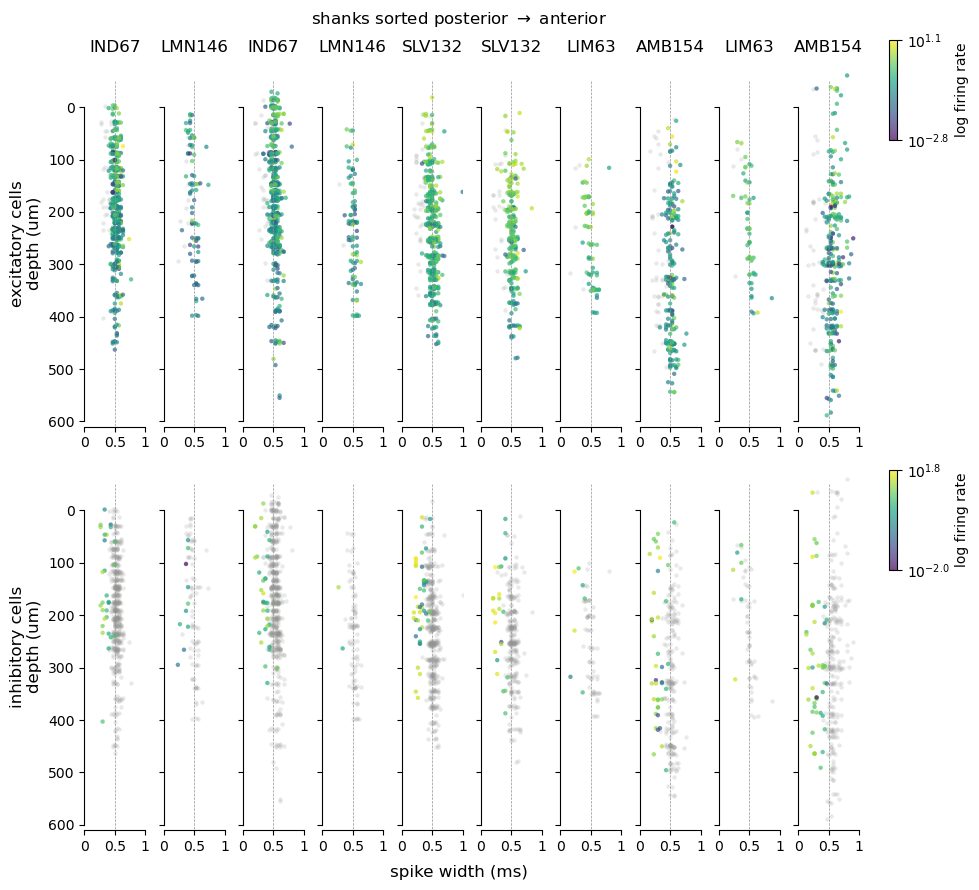

In [111]:
''' Plot things '''
n_birds = len(bird_ids)-1
n_shanks = n_birds*2

# fig params
gs_kw = dict(hspace=0.1, wspace=0.3)
f, ax = plt.subplots(2, n_shanks, figsize=(10, 10),
                     sharey=True, gridspec_kw=gs_kw)
title_size = 14
axis_label = 12
tick_label = 9

# data params
exc_vmax = np.nanmax(log_fr[exc_idx])
exc_vmin = np.nanmin(log_fr[exc_idx])
inhb_vmax = np.nanmax(log_fr[inhb_idx])
inhb_vmin = np.nanmin(log_fr[inhb_idx])

cell_idx_start = 0
i = 0
for bird in bird_ids:
    if bird == 'RBY94':
        continue
        
    # waveform properties
    wf_width = pos_dict[bird]['waveform_props'][1]
    cell_fr = pos_dict[bird]['waveform_props'][2]
    n_cells = wf_width.shape[0]

    # positions
    cell_pos = pos_dict[bird]['cell_pos']
    cell_dv = cell_pos[:, -1]
    _, ap_idx = np.unique(cell_pos[:, 1], return_inverse=True)
    B_idx = ap_idx < 3
    A_idx = ap_idx >= 3

    # cluster indices
    cell_idx_end = cell_idx_start + n_cells
    exc_cells = exc_idx[cell_idx_start:cell_idx_end]
    inhb_cells = inhb_idx[cell_idx_start:cell_idx_end]

    # index by shank and cluster
    B_excite = B_idx & exc_cells
    B_inhib = B_idx & inhb_cells
    A_excite = A_idx & exc_cells
    A_inhib = A_idx & inhb_cells

    # subplot indices
    B_ax = ap_sort_idx[i]
    A_ax = ap_sort_idx[i+1]

    # jitter
    jit = np.random.randn(n_cells)*2

    # highlight the excitatory cells
    sc_exc = ax[0, B_ax].scatter(wf_width[B_excite],
                                 cell_dv[B_excite] + jit[B_excite],
                                 c=cell_fr[B_excite], cmap='viridis',
                                 vmin=exc_vmin, vmax=exc_vmax,
                                 s=10, lw=0, zorder=1, alpha=0.7)
    ax[0, B_ax].scatter(wf_width[B_inhib],
                        cell_dv[B_inhib] + jit[B_inhib], 
                        c='xkcd:gray', 
                        s=10, lw=0, zorder=0, alpha=0.2)
    ax[0, B_ax].vlines(0.5, -50, 610, colors='xkcd:gray', linestyles='dashed', lw=0.5)
    ax[0, A_ax].scatter(wf_width[A_excite], 
                        cell_dv[A_excite] + jit[A_excite],
                        c=cell_fr[A_excite], cmap='viridis', 
                        vmin=exc_vmin, vmax=exc_vmax,
                        s=10, lw=0, zorder=1, alpha=0.7)
    ax[0, A_ax].scatter(wf_width[A_inhib],
                        cell_dv[A_inhib] + jit[A_inhib], 
                        c='xkcd:gray', 
                        s=10, lw=0, zorder=0, alpha=0.2)
    ax[0, A_ax].vlines(0.5, -50, 610, colors='xkcd:gray', linestyles='dashed', lw=0.5)

    # highlight the inhibitory cells
    ax[1, B_ax].scatter(wf_width[B_excite], 
                        cell_dv[B_excite] + jit[B_excite],
                        c='xkcd:gray', 
                        s=10, lw=0, zorder=0, alpha=0.2)
    sc_inhb = ax[1, B_ax].scatter(wf_width[B_inhib],
                                  cell_dv[B_inhib] + jit[B_inhib],
                                  c=cell_fr[B_inhib], cmap='viridis', 
                                  vmin=inhb_vmin, vmax=inhb_vmax,
                                  s=10, lw=0, zorder=1, alpha=0.7)
    ax[1, B_ax].vlines(0.5, -50, 610, colors='xkcd:gray', linestyles='dashed', lw=0.5)
    ax[1, A_ax].scatter(wf_width[A_excite], 
                        cell_dv[A_excite] + jit[A_excite],
                        c='xkcd:gray', 
                        s=10, lw=0, zorder=0, alpha=0.2)
    ax[1, A_ax].scatter(wf_width[A_inhib],
                        cell_dv[A_inhib] + jit[A_inhib], 
                        c=cell_fr[A_inhib], cmap='viridis', 
                        vmin=inhb_vmin, vmax=inhb_vmax,
                        s=10, lw=0, zorder=1, alpha=0.7)
    ax[1, A_ax].vlines(0.5, -50, 610, colors='xkcd:gray', linestyles='dashed', lw=0.5)
    
    # titles
    ax[0, A_ax].set_title(f'{bird}', fontsize=axis_label)
    ax[0, B_ax].set_title(f'{bird}', fontsize=axis_label)
    

    # format axes
    for j in range(2):
        for sh in [B_ax, A_ax]:
            ax[j, sh].set_xlim(0, 1)
            ax[j, sh].spines['right'].set_visible(False)
            ax[j, sh].spines['top'].set_visible(False)
            ax[j, sh].spines['bottom'].set_bounds(0, 1)
            ax[j, sh].spines['left'].set_bounds(600, 0)
            ax[j, sh].set_xticks([0, 0.5, 1])
            ax[j, sh].set_xticklabels(['0', '0.5', '1'])

    # update indices
    i += 2
    cell_idx_start = cell_idx_end

# universal formatting
ax[0, 0].set_ylim([610, -90]) 
ax[0, 0].set_ylabel('excitatory cells\ndepth (um)', fontsize=axis_label)
ax[1, 0].set_ylabel('inhibitory cells\ndepth (um)', fontsize=axis_label)
f.supxlabel('spike width (ms)', fontsize=axis_label, y=0.06)
f.suptitle(r"shanks sorted posterior $\rightarrow$ anterior", fontsize=axis_label, y=0.93)

# colorbars
cax = f.add_axes([0.93, 0.8, 0.008, 0.1])
cbar = f.colorbar(sc_exc, cax=cax)
cbar.set_label('log firing rate')
max_fr = np.round(exc_vmax, 1)
min_fr = np.round(exc_vmin, 1)
cbar.set_ticks([sc_exc.norm.vmin, sc_exc.norm.vmax])
cbar.set_ticklabels([rf'$10^{{{min_fr}}}$', rf'$10^{{{max_fr}}}$'])

cax = f.add_axes([0.93, 0.37, 0.008, 0.1])
cbar = f.colorbar(sc_inhb, cax=cax)
cbar.set_label('log firing rate')
max_fr = np.round(inhb_vmax, 1)
min_fr = np.round(inhb_vmin, 1)
cbar.set_ticks([sc_inhb.norm.vmin, sc_inhb.norm.vmax])
cbar.set_ticklabels([rf'$10^{{{min_fr}}}$', rf'$10^{{{max_fr}}}$'])

f.savefig(f'{save_figs}/wf_width_by_depth_fr.png', dpi=400, bbox_inches='tight')
plt.show()

In [141]:
# check for stim data
stim_sessions = []
for bird in bird_ids:
    if bird == 'RBY94':
        continue
    session_list = data_dict[bird]['all_sessions']
    for session_id in session_list:
        # get the list of stim sessions
        if 'worm_ch_idx' in data_dict[bird][session_id].keys():
            stim_sessions.append(f'{bird}_{session_id}')
            
print(np.setdiff1d(stim_sessions, pos_sessions))

[]


In [144]:
# collect the stim response index (by channel)
stim_resp_idx = np.asarray([])
for bird in bird_ids:
    session_list = data_dict[bird]['all_sessions']
    for session_id in session_list:
        if f'{bird}_{session_id}' in stim_sessions:
            stim_idx = data_dict[bird][session_id]['worm_ch_idx']
            stim_resp_idx = np.append(stim_resp_idx, stim_idx)
            
# get all channel positions
all_ch_pos = []
for bird in bird_ids:
    session_list = data_dict[bird]['all_sessions']
    for session_id in session_list:
        if f'{bird}_{session_id}' in stim_sessions:
            ch_pos = data_dict[bird][session_id]['channel_pos']
            if len(all_ch_pos) == 0:
                all_ch_pos = ch_pos
            else:
                all_ch_pos = np.row_stack([all_ch_pos, ch_pos])

In [145]:
all_ch_pos.shape

(2176, 3)

In [155]:
# for each cell, determine if it is in a stim responsive position
stim_pos = all_ch_pos[stim_resp_idx.astype(bool)]
cell_idx_start = 0
for bird in bird_ids:
    if bird == 'RBY94':
        continue

    # positions
    cell_pos = pos_dict[bird]['cell_pos']
    n_cells = cell_pos.shape[0]
    
    # match positions to channels with stim responses
    cell_stim_idx = np.zeros(n_cells)
    for cell_idx, this_pos in enumerate(cell_pos):
        cell_stim_idx[cell_idx] = np.any(np.all(stim_pos == this_pos, axis=1))
    pos_dict[bird]['cell_stim_idx'] = cell_stim_idx.astype(bool)
    
    pct_stim = np.round(np.sum(cell_stim_idx) / n_cells * 100, 2)
    print(f'{bird}: {pct_stim}% of cells are on stim responsive channels')

LIM63: 76.38% of cells are on stim responsive channels
AMB154: 34.0% of cells are on stim responsive channels
SLV132: 91.2% of cells are on stim responsive channels
IND67: 44.56% of cells are on stim responsive channels
LMN146: 24.32% of cells are on stim responsive channels


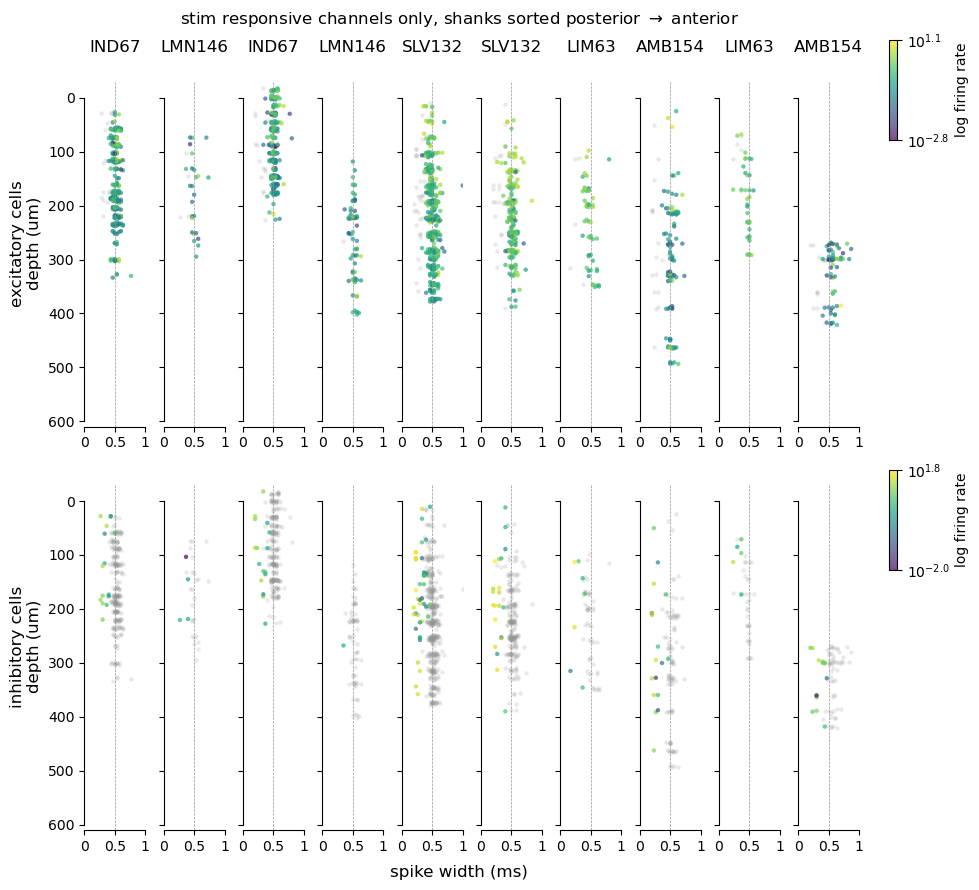

In [160]:
''' Plot only cells on stim responsive channels '''
n_birds = len(bird_ids)-1
n_shanks = n_birds*2

# fig params
gs_kw = dict(hspace=0.1, wspace=0.3)
f, ax = plt.subplots(2, n_shanks, figsize=(10, 10),
                     sharey=True, gridspec_kw=gs_kw)
title_size = 14
axis_label = 12
tick_label = 9

ylim_top = -70

# data params
exc_vmax = np.nanmax(log_fr[exc_idx])
exc_vmin = np.nanmin(log_fr[exc_idx])
inhb_vmax = np.nanmax(log_fr[inhb_idx])
inhb_vmin = np.nanmin(log_fr[inhb_idx])

cell_idx_start = 0
i = 0
for bird in bird_ids:
    if bird == 'RBY94':
        continue
        
    # waveform properties
    wf_width = pos_dict[bird]['waveform_props'][1]
    cell_fr = pos_dict[bird]['waveform_props'][2]
    n_cells = wf_width.shape[0]

    # positions
    cell_pos = pos_dict[bird]['cell_pos']
    cell_dv = cell_pos[:, -1]
    _, ap_idx = np.unique(cell_pos[:, 1], return_inverse=True)
    B_idx = ap_idx < 3
    A_idx = ap_idx >= 3

    # cluster indices
    cell_idx_end = cell_idx_start + n_cells
    exc_cells = exc_idx[cell_idx_start:cell_idx_end]
    inhb_cells = inhb_idx[cell_idx_start:cell_idx_end]
    
    # stim indices
    cell_stim_idx = pos_dict[bird]['cell_stim_idx']

    # index by shank and cluster and stim responsive
    B_excite = B_idx & exc_cells & cell_stim_idx
    B_inhib = B_idx & inhb_cells & cell_stim_idx
    A_excite = A_idx & exc_cells & cell_stim_idx
    A_inhib = A_idx & inhb_cells & cell_stim_idx

    # subplot indices
    B_ax = ap_sort_idx[i]
    A_ax = ap_sort_idx[i+1]

    # jitter
    jit = np.random.randn(n_cells)*2

    # highlight the excitatory cells
    sc_exc = ax[0, B_ax].scatter(wf_width[B_excite],
                                 cell_dv[B_excite] + jit[B_excite],
                                 c=cell_fr[B_excite], cmap='viridis',
                                 vmin=exc_vmin, vmax=exc_vmax,
                                 s=10, lw=0, zorder=1, alpha=0.7)
    ax[0, B_ax].scatter(wf_width[B_inhib],
                        cell_dv[B_inhib] + jit[B_inhib], 
                        c='xkcd:gray', 
                        s=10, lw=0, zorder=0, alpha=0.2)
    ax[0, B_ax].vlines(0.5, ylim_top+40, 610, colors='xkcd:gray', linestyles='dashed', lw=0.5)
    ax[0, A_ax].scatter(wf_width[A_excite], 
                        cell_dv[A_excite] + jit[A_excite],
                        c=cell_fr[A_excite], cmap='viridis', 
                        vmin=exc_vmin, vmax=exc_vmax,
                        s=10, lw=0, zorder=1, alpha=0.7)
    ax[0, A_ax].scatter(wf_width[A_inhib],
                        cell_dv[A_inhib] + jit[A_inhib], 
                        c='xkcd:gray', 
                        s=10, lw=0, zorder=0, alpha=0.2)
    ax[0, A_ax].vlines(0.5, ylim_top+40, 610, colors='xkcd:gray', linestyles='dashed', lw=0.5)

    # highlight the inhibitory cells
    ax[1, B_ax].scatter(wf_width[B_excite], 
                        cell_dv[B_excite] + jit[B_excite],
                        c='xkcd:gray', 
                        s=10, lw=0, zorder=0, alpha=0.2)
    sc_inhb = ax[1, B_ax].scatter(wf_width[B_inhib],
                                  cell_dv[B_inhib] + jit[B_inhib],
                                  c=cell_fr[B_inhib], cmap='viridis', 
                                  vmin=inhb_vmin, vmax=inhb_vmax,
                                  s=10, lw=0, zorder=1, alpha=0.7)
    ax[1, B_ax].vlines(0.5, ylim_top+40, 610, colors='xkcd:gray', linestyles='dashed', lw=0.5)
    ax[1, A_ax].scatter(wf_width[A_excite], 
                        cell_dv[A_excite] + jit[A_excite],
                        c='xkcd:gray', 
                        s=10, lw=0, zorder=0, alpha=0.2)
    ax[1, A_ax].scatter(wf_width[A_inhib],
                        cell_dv[A_inhib] + jit[A_inhib], 
                        c=cell_fr[A_inhib], cmap='viridis', 
                        vmin=inhb_vmin, vmax=inhb_vmax,
                        s=10, lw=0, zorder=1, alpha=0.7)
    ax[1, A_ax].vlines(0.5, ylim_top+40, 610, colors='xkcd:gray', linestyles='dashed', lw=0.5)
    
    # titles
    ax[0, A_ax].set_title(f'{bird}', fontsize=axis_label)
    ax[0, B_ax].set_title(f'{bird}', fontsize=axis_label)
    

    # format axes
    for j in range(2):
        for sh in [B_ax, A_ax]:
            ax[j, sh].set_xlim(0, 1)
            ax[j, sh].spines['right'].set_visible(False)
            ax[j, sh].spines['top'].set_visible(False)
            ax[j, sh].spines['bottom'].set_bounds(0, 1)
            ax[j, sh].spines['left'].set_bounds(600, 0)
            ax[j, sh].set_xticks([0, 0.5, 1])
            ax[j, sh].set_xticklabels(['0', '0.5', '1'])

    # update indices
    i += 2
    cell_idx_start = cell_idx_end

# universal formatting
ax[0, 0].set_ylim([610, ylim_top]) 
ax[0, 0].set_ylabel('excitatory cells\ndepth (um)', fontsize=axis_label)
ax[1, 0].set_ylabel('inhibitory cells\ndepth (um)', fontsize=axis_label)
f.supxlabel('spike width (ms)', fontsize=axis_label, y=0.06)
f.suptitle(r"stim responsive channels only, shanks sorted posterior $\rightarrow$ anterior",
           fontsize=axis_label, y=0.93)

# colorbars
cax = f.add_axes([0.93, 0.8, 0.008, 0.1])
cbar = f.colorbar(sc_exc, cax=cax)
cbar.set_label('log firing rate')
max_fr = np.round(exc_vmax, 1)
min_fr = np.round(exc_vmin, 1)
cbar.set_ticks([sc_exc.norm.vmin, sc_exc.norm.vmax])
cbar.set_ticklabels([rf'$10^{{{min_fr}}}$', rf'$10^{{{max_fr}}}$'])

cax = f.add_axes([0.93, 0.37, 0.008, 0.1])
cbar = f.colorbar(sc_inhb, cax=cax)
cbar.set_label('log firing rate')
max_fr = np.round(inhb_vmax, 1)
min_fr = np.round(inhb_vmin, 1)
cbar.set_ticks([sc_inhb.norm.vmin, sc_inhb.norm.vmax])
cbar.set_ticklabels([rf'$10^{{{min_fr}}}$', rf'$10^{{{max_fr}}}$'])

f.savefig(f'{save_figs}/width_by_depth_stim_only.png', dpi=400, bbox_inches='tight')
plt.show()

In [151]:
np.sum(B_idx)

57

In [152]:
np.sum(exc_cells)

114

In [154]:
np.sum(cell_stim_idx)

97.0